# UR3 Robot Arm: Motion Planning
---

In [1]:
import pyvista as pv
pv.set_jupyter_backend("server")

## Running the UR3 Setup Script

In [2]:
%run ur3_setup.py

## Joint Motion Paths

When creating a `JointSpaceScheme`, the inverse kinematics of the robot arm is used to compute sets of joint coordinates that correspond with the given target frames in Cartesian space. These target joint coordinates are indicated by the points in the plot below. Between these points the motion paths are calculated according to the set `MultiPointMotionProfileType`. In this case `MultiPointMotionProfileType.LINEAR` is set, which means a linear motion path with parabolic blends around the path points. The parabolic blends are calculated based on the specified blend acceleration(s).

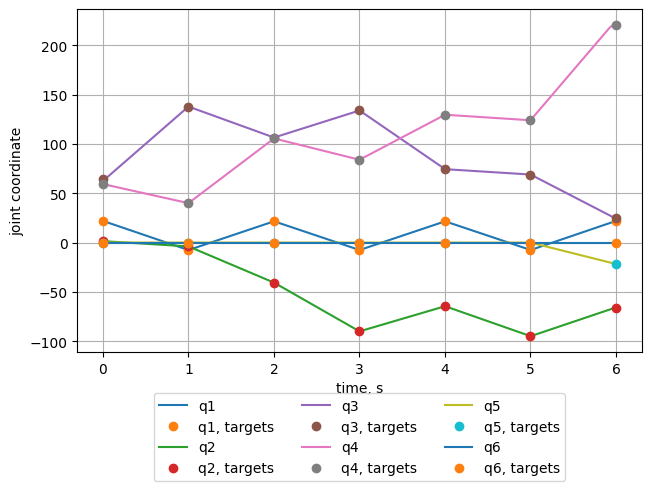

In [3]:
joint_scheme.plot_positions().show()

## Animation of Robot Arm Motion

The motion of the robot arm can be animated by sending the calculated joint coordinates (positions) that lie on the motion paths to the animation function of the UR3 robot arm model. In Jupyter notebooks the asynchronous version of the animation function should be called.

In [4]:
await ur3.animate_async(
    joint_coords=joint_scheme.positions,
    show_ee_path=True,
    gif_path="ur3_motion.gif",
    camera_setup=lambda ws: ws.camera.scale_distance_to_focal_point(0.5, render=False),
)

Widget(value='<iframe src="http://localhost:56439/index.html?ui=P_0x292bcd0bb60_0&reconnect=auto" class="pyvis…

## Plotting the 3D Trajectory in Cartesian Space

A motion computed in the joint space of the robot arm can be translated to Cartesian space using the forward kinematics of the robotarm. For each set of joint coordinates at a time moment $t$ the corresponding pose of the end-effector frame in Cartesian space can be determined.

In [5]:
cartesian_scheme = joint_scheme.to_cartesian_space()

Plot the straight-line trajectory that was defined by specification of the target frames in the UR3 setup script (blue color) and the actual trajectory that follows from motion path planning in the joint space of the robot arm (orange color). 

In [6]:
await cartesian_scheme.plot_trajectory_async(
    extent=0.6,
    spacing=0.1,
    world_frame_scale=0.4,
    target_frame_scale=0.075,
    show_points=False
)

Widget(value='<iframe src="http://localhost:56439/index.html?ui=P_0x2928c43b920_1&reconnect=auto" class="pyvis…